PartⅠ：Data processing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

df_train = pd.read_csv('/kaggle/input/kkbbox-music-recommend/train.csv') 
df_test = pd.read_csv('/kaggle/input/kkbbox-music-recommend/test.csv')   
df_songs = pd.read_csv('/kaggle/input/kkbbox-music-recommend/songs.csv')
df_members = pd.read_csv('/kaggle/input/kkbbox-music-recommend/members.csv')
df_songs_extra = pd.read_csv('/kaggle/input/kkbbox-music-recommend/song_extra_info.csv')

# merge data
df_train = df_train.merge(df_songs, on='song_id', how='left')
df_train = df_train.merge(df_members, on='msno', how='left')
df_train = df_train.merge(df_songs_extra, on='song_id', how='left')

df_test = df_test.merge(df_songs, on='song_id', how='left')
df_test = df_test.merge(df_members, on='msno', how='left')
df_test = df_test.merge(df_songs_extra, on='song_id', how='left')





FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/kkbbox-music-recommend/train.csv'

In [ ]:
df_train.head()

In [ ]:
df_train.info()

In [ ]:
df_test.head()

In [ ]:
df_test.info()

Delete duplicate columns

In [ ]:
# 对df.train处理，获取含有_x _y的列，对比_x _y列，对比哪个列缺失值少，保留该列
dup_cols_train = set()
for col in df_train.columns:
    if '_x' in col:
        base_col = col.replace('_x', '')
        dup_cols_train.add(base_col)
    elif '_y' in col:
        base_col = col.replace('_y', '')
        dup_cols_train.add(base_col)
# print(dup_cols)

for col in dup_cols_train:
    dup_cols_x = col + '_x'
    dup_cols_y = col + '_y'
    if dup_cols_x in df_train.columns and dup_cols_y in df_train.columns:
        if df_train[dup_cols_x].isnull().sum() <= df_train[dup_cols_y].isnull().sum():
            df_train.drop(columns=[dup_cols_y], inplace=True)
            df_train.rename(columns={dup_cols_x: col}, inplace=True)
        else:
            df_train.drop(columns=[dup_cols_x], inplace=True)
            df_train.rename(columns={dup_cols_y: col}, inplace=True)


In [ ]:
# 同样的逻辑处理测试集
dup_cols_test = set()
for col in df_test.columns:
    if '_x' in col:
        base_col = col.replace('_x', '')
        dup_cols_test.add(base_col)
    elif '_y' in col:
        base_col = col.replace('_y', '')
        dup_cols_test.add(base_col)
# print(dup_cols_test)

for col in dup_cols_test:
    dup_cols_x = col + '_x'
    dup_cols_y = col + '_y'
    if dup_cols_x in df_test.columns and dup_cols_y in df_test.columns:
        if df_test[dup_cols_x].isnull().sum() <= df_test[dup_cols_y].isnull().sum():
            df_test.drop(columns=[dup_cols_y], inplace=True)
            df_test.rename(columns={dup_cols_x: col}, inplace=True)
        else:
            df_test.drop(columns=[dup_cols_x], inplace=True)
            df_test.rename(columns={dup_cols_y: col}, inplace=True)

In [2]:
# df_train.isnull().any()
# df_test.isnull().any()

# Handling missing values
df_train['gender'].fillna('Unknown', inplace=True)
df_test['gender'].fillna('Unknown', inplace=True)


df_train['source_system_tab'].fillna(value="Unknown",inplace=True)
df_test['source_system_tab'].fillna(value="Unknown",inplace=True)


df_train['source_screen_name'].fillna(value="Unknown",inplace=True)
df_test['source_screen_name'].fillna(value="Unknown",inplace=True)

df_train['source_type'].fillna(value="Unknown",inplace=True)
df_test['source_type'].fillna(value="Unknown",inplace=True)

df_train['genre_ids'].fillna(value="Unknown",inplace=True)
df_test['genre_ids'].fillna(value="Unknown",inplace=True)

df_train['artist_name'].fillna(value="Unknown",inplace=True)
df_test['artist_name'].fillna(value="Unknown",inplace=True)

df_train['composer'].fillna(value="Unknown",inplace=True)
df_test['composer'].fillna(value="Unknown",inplace=True)

df_train['lyricist'].fillna(value="Unknown",inplace=True)
df_test['lyricist'].fillna(value="Unknown",inplace=True)

# 平均值填充歌曲时长的缺失值
df_train['song_length'].fillna(df_train['song_length'].mean(), inplace=True)
df_test['song_length'].fillna(df_test['song_length'].mean(), inplace=True)

# 众数填充语言缺失值
df_train['language'].fillna(df_train['language'].mode()[0], inplace=True)
df_test['language'].fillna(df_test['language'].mode()[0], inplace=True)


NameError: name 'df_train' is not defined

In [3]:
df_test.isnull().any()

NameError: name 'df_test' is not defined

PartⅡ: Feature engineering

1、处理genre_ids列，量化作曲家数量和标签数量作为特征

In [4]:
# genre_ids 处理，将多个genre拆分为列表，并统计个数
df_train['genre_ids'] = df_train['genre_ids'].str.split('|')
df_test['genre_ids'] = df_test['genre_ids'].str.split('|')

# apply方法，对每个元素执行定义函数
df_train['genre_count'] = df_train['genre_ids'].apply(lambda x: len(x) if 'Unknown' not in x else 0)
df_test['genre_count'] = df_test['genre_ids'].apply(lambda x: len(x) if 'Unknown' not in x else 0)

NameError: name 'df_train' is not defined

In [5]:
# composer 处理，与genre_ids逻辑相同
df_train['composer_count'] = df_train['composer'].apply(lambda x: len(x.split('|')) if 'Unknown' not in x.split('|') else 0)
df_test['composer_count'] = df_test['composer'].apply(lambda x: len(x.split('|')) if 'Unknown' not in x.split('|') else 0)

NameError: name 'df_train' is not defined

In [6]:
# 删除冗余composer列
df_train.drop(columns=['composer'], inplace=True)
df_test.drop(columns=['composer'], inplace=True)

NameError: name 'df_train' is not defined

2、处理歌手列，歌手是影响用户重复收听行为的关键因素，若一个歌手的歌曲 “重复收听率高”，说明其作品风格更契合用户偏好（比如周杰伦的粉丝常重复收听他的歌）；
反之，重复收听率低的歌手，其作品可能仅被用户 “听过一次就跳过”。

量化方法：
1）按artist_name分组，统计repeat_count（该歌手的歌曲被重复收听的总次数）和play_count（该歌手的歌曲被收听的总次数）。repeat_count反映 “用户对该歌手的偏好强度”，play_count反映 “歌手的 popularity 基础”。
2）计算repeat_percentage = (repeat_count / play_count) * 100；
“重复率” 是 “偏好强度” 与 “popularity” 的结合（比如一个歌手播放量高但重复率低，说明作品 “听过但不爱听”；播放量低但重复率高，说明是 “小众但精准的偏好”），这个指标能更全面地刻画歌手对用户重复收听行为的影响。

In [7]:
df_train['artist_name'].nunique()

NameError: name 'df_train' is not defined

In [124]:
df_test['artist_name'].nunique()

27564

In [125]:
# 只有训练和测试都存在的歌手，其 “重复收听率” 特征才能在测试集生效，避免因 “测试集歌手未在训练集出现” 导致特征缺失。
print("Number of Common Artists in both train & Test : ", len(set.intersection(set(df_train['artist_name']), set(df_test['artist_name']))))

Number of Common Artists in both train & Test :  21774


In [126]:
# 按artist_name分组计算重复播放次数与播放次数
df_artists = df_train.loc[:,["artist_name","target"]]

# 重复次数
artist1 = df_artists.groupby('artist_name', as_index=False).sum().rename(columns={'target':'repeat_count'})
# 播放次数
artist2 = df_artists.groupby('artist_name', as_index=False).count().rename(columns={'target':'play_count'})

In [127]:
df_artist_repeats = artist1.merge(artist2,how="inner",on="artist_name")

In [128]:
df_artist_repeats.head()

,artist_name,repeat_count,play_count
0,!Conz,1,1
1,!magnic!,0,1
2,#037 (#037),20,84
3,#1 Beatles Now,7,32
4,#1 Club Hits - Best Of Dance & Techno,5,7


In [129]:
# 重复播放比
df_artist_repeats['repeat_percentage'] = round(((df_artist_repeats['repeat_count'] / df_artist_repeats['play_count']) * 100), 1)

In [130]:
df_artist_repeats.head()

,artist_name,repeat_count,play_count,repeat_percentage
0,!Conz,1,1,100.0
1,!magnic!,0,1,0.0
2,#037 (#037),20,84,23.8
3,#1 Beatles Now,7,32,21.9
4,#1 Club Hits - Best Of Dance & Techno,5,7,71.4


In [131]:
# 将重复播放比列添加到训练、测试集中
df_artist_repeats.drop(["repeat_count","play_count"],axis=1,inplace=True)

df_train = df_train.merge(df_artist_repeats, on='artist_name', how='left').rename(columns = {'repeat_percentage':'artist_repeat_percentage'})

df_test = df_test.merge(df_artist_repeats,on="artist_name",how="left").rename(columns={"repeat_percentage":"artist_repeat_percentage"})


In [132]:
# 删除冗余
df_train.drop(['genre_ids', 'artist_name'], axis=1, inplace=True)
df_test.drop(['genre_ids', 'artist_name'], axis=1, inplace=True)



In [133]:
del df_artist_repeats
del df_artists


3、处理 来源相关列，分析用户使用场景，反映其使用习惯和需求

In [134]:
df_train['source_system_tab'].value_counts()

source_system_tab
my library      3684730
discover        2179252
search           623286
radio            476701
listen with      212266
explore          167949
Unknown           24849
notification       6185
settings           2200
Name: count, dtype: int64

In [135]:
# 构建映射字典（高频场景值越大）
source_tab_dict = {
    "my library":8,
    "discover":7,
    "search":6,
    "radio":5,
    "listen with":4,
    "explore":3,
    "notification":2,
    "settings":1,
    "Unknown":0
}

# 用map方法将原始类别替换为数值
df_train['source_system_tab'] = df_train['source_system_tab'].map(source_tab_dict)
df_test['source_system_tab'] = df_test['source_system_tab'].map(source_tab_dict)

In [136]:
# 同样的逻辑处理
df_train['source_screen_name'].value_counts()

source_screen_name
Local playlist more     3228202
Online playlist more    1294689
Radio                    474467
Unknown                  468974
Album more               420156
Search                   298487
Artist more              252429
Discover Feature         244246
Discover Chart           213658
Others profile more      201795
Discover Genre            82202
My library                75980
Explore                   72342
Discover New              15955
Search Trends             13632
Search Home               13482
My library_Search          6451
Self profile more           212
Concert                      47
Payment                      12
Name: count, dtype: int64

In [137]:
source_screen_dict = {
    'Local playlist more':19,
    'Online playlist more':18,   
    'Radio':17, 
    'Unknown':16,                
    'Album more':15,              
    'Search':14,                  
    'Artist more':13,             
    'Discover Feature':12,         
    'Discover Chart':11,           
    'Others profile more':10,      
    'Discover Genre':9,            
    'My library':8,               
    'Explore':7,                   
    'Discover New':6,             
    'Search Trends':5,             
    'Search Home':4,          
    'My library_Search':3,        
    'Self profile more':2,        
    'Concert':1,                  
    'Payment':0                   
}

df_train['source_screen_name'] = df_train['source_screen_name'].map(source_screen_dict)
df_test['source_screen_name'] = df_test['source_screen_name'].map(source_screen_dict)

In [138]:
df_train['source_type'].value_counts()

source_type
local-library             2261399
online-playlist           1967924
local-playlist            1079503
radio                      483109
album                      477344
top-hits-for-artist        423614
song                       244722
song-based-playlist        210527
listen-with                192842
Unknown                     21539
topic-article-playlist      11194
artist                       3038
my-daily-playlist             663
Name: count, dtype: int64

In [139]:
source_type_dict = {
    "local-library":12,
    "online-playlist":11,
    "local-playlist":10,
    "radio":9,
    "album":8,
    "top-hits-for-artist":7,
    "song":6,
    "song-based-playlist":5,
    "listen-with":4,
    "Unknown":3,
    "topic-article-playlist":2,
    "artist":1,
    "my-daily-playlist":0
}

df_train['source_type'] = df_train['source_type'].map(source_type_dict)
df_test['source_type'] = df_test['source_type'].map(source_type_dict)


In [140]:
df_test.isnull().any()

id                          False
msno                        False
song_id                     False
source_system_tab           False
source_screen_name           True
source_type                 False
song_length                 False
lyricist                    False
language                    False
city                        False
bd                          False
gender                      False
registered_via              False
registration_init_time      False
expiration_date             False
name                         True
isrc                         True
genre_count                 False
composer_count              False
artist_repeat_percentage     True
dtype: bool

4、处理性别列（用户性别与喜欢的歌曲有强相关性）

In [141]:
# 处理性别列（性别与喜欢的歌曲有相关性）
# 独热编码性别(删掉一列，排除完全共线性 unknown+male+female = 1)
gender_train = pd.get_dummies(df_train['gender'], drop_first=True)
gender_test = pd.get_dummies(df_test['gender'], drop_first=True)

# 合并独热编码后的性别特征
df_train = pd.concat([df_train, gender_train], axis=1)
df_test = pd.concat([df_test, gender_test], axis=1)




In [142]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 22 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   msno                      object 
 1   song_id                   object 
 2   source_system_tab         int64  
 3   source_screen_name        int64  
 4   source_type               int64  
 5   target                    int64  
 6   song_length               float64
 7   lyricist                  object 
 8   language                  float64
 9   city                      int64  
 10  bd                        int64  
 11  gender                    object 
 12  registered_via            int64  
 13  registration_init_time    int64  
 14  expiration_date           int64  
 15  name                      object 
 16  isrc                      object 
 17  genre_count               int64  
 18  composer_count            int64  
 19  artist_repeat_percentage  float64
 20  female                  

In [143]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556790 entries, 0 to 2556789
Data columns (total 22 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   id                        int64  
 1   msno                      object 
 2   song_id                   object 
 3   source_system_tab         int64  
 4   source_screen_name        float64
 5   source_type               int64  
 6   song_length               float64
 7   lyricist                  object 
 8   language                  float64
 9   city                      int64  
 10  bd                        int64  
 11  gender                    object 
 12  registered_via            int64  
 13  registration_init_time    int64  
 14  expiration_date           int64  
 15  name                      object 
 16  isrc                      object 
 17  genre_count               int64  
 18  composer_count            int64  
 19  artist_repeat_percentage  float64
 20  female                  

In [144]:
# 删除冗余gender列
df_train.drop(['gender'], axis=1, inplace=True)
df_test.drop(['gender'], axis=1, inplace=True)

In [145]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 21 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   msno                      object 
 1   song_id                   object 
 2   source_system_tab         int64  
 3   source_screen_name        int64  
 4   source_type               int64  
 5   target                    int64  
 6   song_length               float64
 7   lyricist                  object 
 8   language                  float64
 9   city                      int64  
 10  bd                        int64  
 11  registered_via            int64  
 12  registration_init_time    int64  
 13  expiration_date           int64  
 14  name                      object 
 15  isrc                      object 
 16  genre_count               int64  
 17  composer_count            int64  
 18  artist_repeat_percentage  float64
 19  female                    bool   
 20  male                    

5、处理会员有效期列：会员有效期长短反映用户对平台的忠诚度（长期会员更可能深度使用、重复收听歌曲）

In [146]:
df_train['expiration_date'] = pd.to_datetime(df_train['expiration_date'], format='%Y%m%d')
df_train['registration_init_time'] = pd.to_datetime(df_train['registration_init_time'], format='%Y%m%d')

df_test['expiration_date'] = pd.to_datetime(df_test['expiration_date'], format='%Y%m%d')
df_test['registration_init_time'] = pd.to_datetime(df_test['registration_init_time'], format='%Y%m%d')

df_train['validity_days'] = (df_train['expiration_date'] - df_train['registration_init_time']).dt.days
df_test['validity_days'] = (df_test['expiration_date'] - df_test['registration_init_time']).dt.days

In [147]:
# 删除冗余日期列
df_train.drop(['expiration_date', 'registration_init_time'], axis=1, inplace=True)
df_test.drop(['expiration_date', 'registration_init_time'], axis=1, inplace=True)

In [148]:
# df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556790 entries, 0 to 2556789
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   id                        int64  
 1   msno                      object 
 2   song_id                   object 
 3   source_system_tab         int64  
 4   source_screen_name        float64
 5   source_type               int64  
 6   song_length               float64
 7   lyricist                  object 
 8   language                  float64
 9   city                      int64  
 10  bd                        int64  
 11  registered_via            int64  
 12  name                      object 
 13  isrc                      object 
 14  genre_count               int64  
 15  composer_count            int64  
 16  artist_repeat_percentage  float64
 17  female                    bool   
 18  male                      bool   
 19  validity_days             int64  
dtypes: bool(2), float64(4), 

6、处理lyricist列，作曲家数量与歌曲的创作复杂度相关，关联 创作复杂度与用户偏好

In [149]:
df_train['lyricist'] = df_train['lyricist'].str.replace(r'[、\-/|+]', '|', regex=True)
df_test['lyricist'] = df_test['lyricist'].str.replace(r'[、\-/|+]', '|', regex=True)


In [150]:
df_test.head(30)

,id,msno,song_id,source_system_tab,source_screen_name,source_type,song_length,lyricist,language,city,bd,registered_via,name,isrc,genre_count,composer_count,artist_repeat_percentage,female,male,validity_days
0,0,V8ruy7SGk7tDm3zA51DPpn6qutt+vmKMBKa21dp54uM=,WmHKgKMlp1lQMecNdNvDMkvIycZYHnFwDT72I5sIssc=,8,19.0,12,224130.0,Unknown,3.0,1,0,7,愛其實很殘忍,TWUM71400047,1,1,52.0,False,False,577
1,1,V8ruy7SGk7tDm3zA51DPpn6qutt+vmKMBKa21dp54uM=,y/rsZ9DC7FwK5F2PK2D5mj+aOBUJAjuu3dZ14NgE0vM=,8,19.0,12,320470.0,孫燕姿|易家揚,3.0,1,0,7,她說,TWB671005201,1,1,58.6,False,False,577
2,2,/uQAlrAkaczV+nWCd2sPF2ekvXPRipV7q0l+gbLuxjw=,8eZLFOdGVdXBSqoAv5nsLigeH2BvKXzTQYtUM53I0k4=,7,16.0,5,315899.0,Yu Takahashi,17.0,1,0,4,subarashiki nichijo,JPWP01070260,1,1,28.9,False,False,7
3,3,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,ztCf8thYsS4YN3GcIL/bvoxLm/T5mYBVKOO4C9NiVfQ=,5,17.0,9,285210.0,Unknown,52.0,3,30,9,Hold Me| Thrill Me| Kiss Me| Kill Me,GBAAN0201228,1,4,32.7,False,True,3567
4,4,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,MKVMpslKcQhMaFEgcEQhEfi5+RZhMYlU3eRDpySrH8Y=,5,17.0,9,197590.0,Unknown,-1.0,3,30,9,Om Yoga,ITO101121898,1,1,32.8,False,True,3567
5,5,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,NV3nhEcMqsawwvSNTUAt9IVAexHLOm0lDfrHyEfN5B0=,5,17.0,9,216372.0,Unknown,31.0,3,30,9,1|2|3|4,TWA531300295,1,0,50.8,False,True,3567
6,6,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,DPM6G9RB5QO2dvAVPyc70gxHdvu872IjTUvV6LJT8ho=,5,17.0,9,200306.0,BoA | Joe Belmaati,31.0,3,30,9,The Shadow,KRA301200363,1,1,40.8,False,True,3567
7,7,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,JGXB3PHc0CX0JskwwjmYP8i318BLo7DhChgEj6Yqjt8=,8,19.0,10,344305.0,陳信榮,3.0,3,30,9,黃昏,TWA470053008,1,1,53.2,False,True,3567
8,8,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,507plIkmke1jh3wMrHqKore82pPFozADwydR8P0Gx2Q=,5,17.0,9,289332.0,嚴藝丹,3.0,3,30,9,三寸天堂,CNR211200331,1,1,59.1,False,True,3567
9,9,3ZQ6oGfcSiUoCrtBPKGa8hHCiFh5jqtDqPVDUl/zrjU=,HsgJXv1C7iVZiP7CWwWTfsmMhia6Huc0MUccfj+D02o=,8,19.0,12,232176.0,Unknown,31.0,1,0,7,FANTASTIC BABY- (冠軍曲),SGA051200112,1,0,57.0,False,False,639


In [151]:
df_train['lyricist'] = df_train['lyricist'].str.split('|')
df_test['lyricist'] = df_test['lyricist'].str.split('|') 

df_train['lyricist_count'] = df_train['lyricist'].apply(lambda x: len(x) if 'Unknown' not in x else 0)
df_test['lyricist_count'] = df_test['lyricist'].apply(lambda x: len(x) if 'Unknown' not in x else 0)

In [152]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 21 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   msno                      object 
 1   song_id                   object 
 2   source_system_tab         int64  
 3   source_screen_name        int64  
 4   source_type               int64  
 5   target                    int64  
 6   song_length               float64
 7   lyricist                  object 
 8   language                  float64
 9   city                      int64  
 10  bd                        int64  
 11  registered_via            int64  
 12  name                      object 
 13  isrc                      object 
 14  genre_count               int64  
 15  composer_count            int64  
 16  artist_repeat_percentage  float64
 17  female                    bool   
 18  male                      bool   
 19  validity_days             int64  
 20  lyricist_count          

In [153]:
df_train.drop(['lyricist'], axis=1, inplace=True)
df_test.drop(['lyricist'], axis=1, inplace=True)


7、处理歌曲信息码，提取歌曲年份信息，建立歌曲年份与用户偏好之间的关联

In [154]:
# 提取信息码中的年份信息字段
def isrc_to_year(isrc):
    if type(isrc) == str:
        # 由于该数据集产生于2017年，且通常不会超过100年范围，因此以17为分界线，>17基本为19XX年，<17基本为20XX年
        if int(isrc[5:7]) > 17:
            return 1900 + int(isrc[5:7])
        else:
            return 2000 + int(isrc[5:7])
    else:
        return np.nan

df_train['song_year'] = df_train['isrc'].apply(isrc_to_year)
df_test['song_year'] = df_test['isrc'].apply(isrc_to_year)



In [155]:
df_train.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,language,city,bd,...,name,isrc,genre_count,composer_count,artist_repeat_percentage,female,male,validity_days,lyricist_count,song_year
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,3,7,11,1,206471.0,52.0,1,0,...,Good Grief,GBUM71602854,1,2,46.3,False,False,2103,0,2016.0
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,8,19,10,1,284584.0,52.0,13,24,...,Lords of Cardboard,US3C69910183,1,0,51.0,True,False,2301,0,1999.0
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,8,19,10,1,225396.0,52.0,13,24,...,Hip Hop Is Dead(Album Version (Edited)),USUM70618761,1,1,21.5,True,False,2301,0,2006.0
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,8,19,10,1,255512.0,-1.0,13,24,...,Disco Africa,GBUQH1000063,1,1,100.0,True,False,2301,0,2010.0
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,3,7,11,1,187802.0,52.0,1,0,...,Sleep Without You,QM3E21606003,1,3,37.7,False,False,2103,0,2016.0


In [156]:
df_train.isnull().any()

msno                        False
song_id                     False
source_system_tab           False
source_screen_name          False
source_type                 False
target                      False
song_length                 False
language                    False
city                        False
bd                          False
registered_via              False
name                         True
isrc                         True
genre_count                 False
composer_count              False
artist_repeat_percentage    False
female                      False
male                        False
validity_days               False
lyricist_count              False
song_year                    True
dtype: bool

In [157]:
# 处理空值（无可靠年代，因此用-1填充）
df_train['song_year'].fillna(-1, inplace=True)
df_test['song_year'].fillna(-1, inplace=True)

# 转换类型, 模型易处理
df_train['song_year'] = df_train['song_year'].astype(int)
df_test['song_year'] = df_test['song_year'].astype(int)

df_train.isnull().any()
 

/tmp/ipykernel_48/2244834766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['song_year'].fillna(-1, inplace=True)
/tmp/ipykernel_48/2244834766.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

msno                        False
song_id                     False
source_system_tab           False
source_screen_name          False
source_type                 False
target                      False
song_length                 False
language                    False
city                        False
bd                          False
registered_via              False
name                         True
isrc                         True
genre_count                 False
composer_count              False
artist_repeat_percentage    False
female                      False
male                        False
validity_days               False
lyricist_count              False
song_year                   False
dtype: bool

In [158]:
# 删除冗余列
df_train.drop(['isrc'], axis=1, inplace=True)
df_test.drop(['isrc'], axis=1, inplace=True)

In [159]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   msno                      object 
 1   song_id                   object 
 2   source_system_tab         int64  
 3   source_screen_name        int64  
 4   source_type               int64  
 5   target                    int64  
 6   song_length               float64
 7   language                  float64
 8   city                      int64  
 9   bd                        int64  
 10  registered_via            int64  
 11  name                      object 
 12  genre_count               int64  
 13  composer_count            int64  
 14  artist_repeat_percentage  float64
 15  female                    bool   
 16  male                      bool   
 17  validity_days             int64  
 18  lyricist_count            int64  
 19  song_year                 int64  
dtypes: bool(2), float64(3), 

8、处理用户年龄列，建立年龄段与音乐偏好的关联

In [160]:
print(df_train['bd'].min())
print(df_train['bd'].max())
# <0异常 儿童 青少年 成人 中年 老年 超过常规年龄
# df_train['age_range'] = pd.cut(df_train['bd'], bins=[-45,0,12,18,35,50,90,1055])
# df_test['age_range'] = pd.cut(df_test['bd'], bins=[-45,0,12,18,35,50,90,1055])

# 创建年龄类别编号
combine = [df_train, df_test]
for dataset in combine:
    dataset.loc[(dataset['bd'] <= 0) & (dataset['bd'] > -45), 'age_category'] = 0
    dataset.loc[(dataset['bd'] > 0) & (dataset['bd'] <= 12), 'age_category'] = 1
    dataset.loc[(dataset['bd'] > 12) & (dataset['bd'] < 18), 'age_category'] = 2
    dataset.loc[(dataset['bd'] >= 18) & (dataset['bd'] <= 35), 'age_category'] = 3
    dataset.loc[(dataset['bd'] > 35) & (dataset['bd'] <= 50), 'age_category'] = 4
    dataset.loc[(dataset['bd'] > 50) & (dataset['bd'] <= 90), 'age_category'] = 5
    dataset.loc[(dataset['bd'] > 90) & (dataset['bd'] <= 1055), 'age_category'] = 6






-43
1051


In [161]:
# 删除冗余列
df_train.drop(['bd'], axis=1, inplace=True)
df_test.drop(['bd'], axis=1, inplace=True)

In [162]:
print(df_train.info())
# df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   msno                      object 
 1   song_id                   object 
 2   source_system_tab         int64  
 3   source_screen_name        int64  
 4   source_type               int64  
 5   target                    int64  
 6   song_length               float64
 7   language                  float64
 8   city                      int64  
 9   registered_via            int64  
 10  name                      object 
 11  genre_count               int64  
 12  composer_count            int64  
 13  artist_repeat_percentage  float64
 14  female                    bool   
 15  male                      bool   
 16  validity_days             int64  
 17  lyricist_count            int64  
 18  song_year                 int64  
 19  age_category              float64
dtypes: bool(2), float64(4), 

9、类别类信息转换为category类型

In [163]:
df_train['source_system_tab'] = df_train['source_system_tab'].astype("category")
df_test['source_system_tab'] = df_test['source_system_tab'].astype("category")

df_train['source_screen_name'] = df_train['source_screen_name'].astype("category")
df_test['source_screen_name'] = df_test['source_screen_name'].astype("category")

df_train['source_type'] = df_train['source_type'].astype("category")
df_test['source_type'] = df_test['source_type'].astype("category")

df_train['language'] = df_train['language'].astype("category")
df_test['language'] = df_test['language'].astype("category")

df_train['city'] = df_train['city'].astype("category")
df_test['city'] = df_test['city'].astype("category")


df_train['registered_via'] = df_train['registered_via'].astype("category")
df_test['registered_via'] = df_test['registered_via'].astype("category")

df_train['age_category'] = df_train['age_category'].astype("category")
df_test['age_category'] = df_test['age_category'].astype("category")

In [164]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556790 entries, 0 to 2556789
Data columns (total 20 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   id                        int64   
 1   msno                      object  
 2   song_id                   object  
 3   source_system_tab         category
 4   source_screen_name        category
 5   source_type               category
 6   song_length               float64 
 7   language                  category
 8   city                      category
 9   registered_via            category
 10  name                      object  
 11  genre_count               int64   
 12  composer_count            int64   
 13  artist_repeat_percentage  float64 
 14  female                    bool    
 15  male                      bool    
 16  validity_days             int64   
 17  lyricist_count            int64   
 18  song_year                 int64   
 19  age_category              category
dtypes:

In [165]:
df_train.drop('name', axis=1, inplace=True)
df_test.drop('name', axis=1, inplace=True)

PartⅢ: Model training and prediction

In [166]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split  # 拆分验证集
from sklearn.metrics import roc_auc_score  # 手动计算AUC
import matplotlib.pyplot as plt  # 可视化特征重要性


# 提取特征和标签
feature_cols = df_train.drop(["msno", "song_id", "target"], axis=1).columns
X = df_train[feature_cols]
y = df_train['target']

# 拆分数据集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [57]:
# 仅保留真正的分类特征（剔除数值特征）
categorical_features = [
    'age_category', 'city', 'language',
    'source_system_tab', 'source_screen_name', 'source_type',
    'registered_via', 'male', 'female'
]
print(f"分类特征：{categorical_features}")

# 确保分类特征为category类型
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

分类特征：['age_category', 'city', 'language', 'source_system_tab', 'source_screen_name', 'source_type', 'registered_via', 'male', 'female']


In [60]:
params = {
    'learning_rate': 0.05,
    'application': 'binary',
    'max_depth': 6,
    'num_leaves': 31,
    'verbosity': 1,
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'bagging_fraction': 0.8,
    'feature_fraction': 0.8,
    'random_state': 42
}

In [61]:
model = lgb.train(
    params,
    train_set=d_train,
    num_boost_round=1000,
    valid_sets=watchlist,
    callbacks=[
        lgb.log_evaluation(50),
        lgb.early_stopping(50)
    ]
)

print(f"最佳迭代轮次：{model.best_iteration}")
print(f"验证集最佳AUC：{model.best_score['valid_1']['auc']:.4f}")

[LightGBM] [Info] Number of positive: 2971725, number of negative: 2930209
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.343412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11737
[LightGBM] [Info] Number of data points in the train set: 5901934, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503517 -> initscore=0.014069
[LightGBM] [Info] Start training from score 0.014069
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.706978	valid_1's auc: 0.706109
[100]	training's auc: 0.716289	valid_1's auc: 0.714667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

特征重要性（前10名）：
                          特征           重要性
12             validity_days  3.611824e+06
2                source_type  3.081117e+06
9   artist_repeat_percentage  1.752362e+06
1         source_screen_name  1.600927e+06
3                song_length  1.456731e+06
5                       city  3.042616e+05
0          source_system_tab  2.794028e+05
14                 song_year  2.215347e+05
6             registered_via  1.005034e+05
4                   language  4.608685e+04


<Figure size 1000x600 with 0 Axes>

c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: G

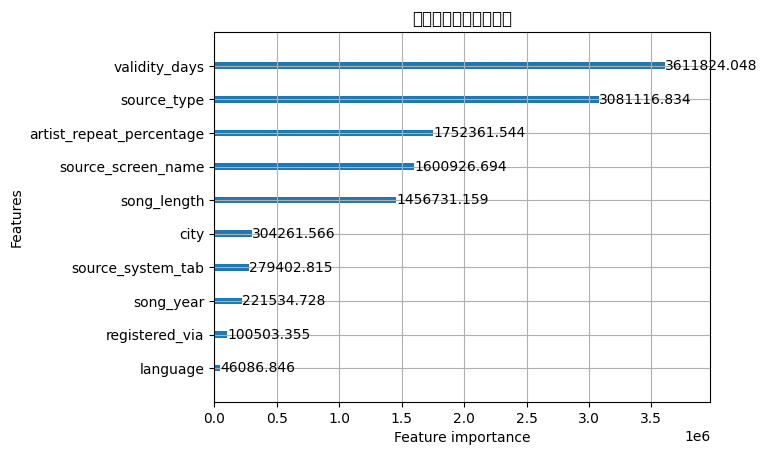

In [62]:
feature_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': model.feature_importance(importance_type='gain')
}).sort_values(by='重要性', ascending=False)
print("特征重要性（前10名）：")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title('特征重要性（按增益）')
plt.show()

In [67]:
# 1. 提取测试集特征（与训练集feature_cols完全一致）
feature_cols = df_train.drop(["msno", "song_id", "target"], axis=1).columns
X_test = df_test[feature_cols].copy()

# 2. 明确分类特征列
categorical_features = [
    'source_system_tab', 'source_screen_name', 'source_type',
    'language', 'city', 'registered_via', 'age_category'
]

# 3. 强制分类特征类别与训练集完全对齐
for col in categorical_features:
    train_cats = X_train[col].cat.categories
    X_test[col] = X_test[col].cat.set_categories(train_cats)
    missing_test_cats = [cat for cat in X_test[col].cat.categories if cat not in train_cats]
    if missing_test_cats:
        X_test[col] = X_test[col].replace(missing_test_cats, X_train[col].mode()[0])
    if X_test[col].isnull().any():
        X_test[col] = X_test[col].fillna(X_train[col].mode()[0])

# 4. 预测概率
y_preds = model.predict(X_test, num_iteration=model.best_iteration)
y_preds = np.clip(y_preds, 0, 1)

In [68]:
result_df = pd.DataFrame({
    'id': df_test['id'],
    'target': y_preds
})

assert not result_df.isnull().any().any(), "结果存在缺失值！"
assert (result_df['target'] >= 0).all() and (result_df['target'] <= 1).all(), "预测概率超出[0,1]范围！"

result_df.to_csv(
    'submission_optimized.csv.gz',
    compression='gzip',
    index=False,
    float_format='%.6f'
)
print("结果文件保存成功！")

结果文件保存成功！


算法二：应用UserCF

Step1：构建用户物品交互稀疏矩阵

In [54]:
interactions = df_train[['msno', 'song_id', 'target']].copy()

# 去重
interactions = interactions.drop_duplicates(subset=['msno', 'song_id'], keep='last')

In [55]:
# interactions.head()
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   msno     object
 1   song_id  object
 2   target   int64 
dtypes: int64(1), object(2)
memory usage: 168.9+ MB


In [56]:
# 将id转换为整数索引
# 构建映射字典
user_id = interactions['msno'].unique().tolist()
songs_id = interactions['song_id'].unique().tolist()

user_id_map = {id:x for x, id in enumerate(user_id)}
song_id_map = {id:x for x, id in enumerate(songs_id)}


In [57]:
# 构建矩阵
# 用字典映射，将索引转换为整数
interactions['user_idx'] = interactions['msno'].map(user_id_map).values
interactions['song_idx'] = interactions['song_id'].map(song_id_map).values

interactions = interactions.drop(['msno', 'song_id'], axis=1)

interactions.head()

,target,user_idx,song_idx
0,1,0,0
1,1,1,1
2,1,1,2
3,1,1,3
4,1,0,4


In [58]:
from scipy.sparse import csr_matrix 

In [59]:
row = interactions['user_idx'].values
col = interactions['song_idx'].values
data = interactions['target'].values

user_item_matrix = csr_matrix((data, (row, col)), shape=(len(user_id), len(songs_id)))

step2：建立用户间余弦相似度矩阵

In [60]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)

print("用户相似度矩阵：")
print(user_similarity)

用户相似度矩阵：
[[1.         0.08630286 0.11962964 ... 0.         0.02185694 0.        ]
 [0.08630286 1.         0.07000812 ... 0.         0.02686077 0.        ]
 [0.11962964 0.07000812 1.         ... 0.         0.02482223 0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.02185694 0.02686077 0.02482223 ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [61]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556790 entries, 0 to 2556789
Data columns (total 19 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   id                        int64   
 1   msno                      object  
 2   song_id                   object  
 3   source_system_tab         category
 4   source_screen_name        category
 5   source_type               category
 6   song_length               float64 
 7   language                  category
 8   city                      category
 9   registered_via            category
 10  genre_count               int64   
 11  composer_count            int64   
 12  artist_repeat_percentage  float64 
 13  female                    bool    
 14  male                      bool    
 15  validity_days             int64   
 16  lyricist_count            int64   
 17  song_year                 int64   
 18  age_category              category
dtypes: bool(2), category(7), float64(2), int64

预计算所有用户对歌曲的预测概率

In [ ]:
import numpy as np

# 1. 定义超参数K（相似用户数量，可调，建议10-50）
K = 20

# 2. 预存每个用户的Top-K相似用户（索引+相似度）
user_topk_similar = []
for user_idx in range(user_similarity.shape[0]):  # 遍历所有用户
    # 获取当前用户与其他所有用户的相似度
    sim_scores = user_similarity[user_idx].copy()  # 形状：[用户数]
    
    # 排除自身（避免用自己的行为预测自己）
    sim_scores[user_idx] = -1  # 将自身相似度设为最小值，确保不被选中
    
    # 按相似度降序排序，取前K个用户
    topk_indices = np.argsort(sim_scores)[::-1][:K]  # 前K个最相似用户的索引
    topk_sims = sim_scores[topk_indices]  # 对应的相似度分数
    
    user_topk_similar.append((topk_indices, topk_sims))

print(f"完成{len(user_topk_similar)}个用户的Top-{K}相似用户预计算")

完成30755个用户的Top-20相似用户预计算


处理冷启动（新用户 / 新歌曲无历史交互）

In [63]:
import pandas as pd

# 1. 计算全局平均重复收听率（冷启动兜底值）
# 假设interactions是预处理后的交互数据（含'target'列）
global_avg_target = interactions['target'].mean()
print(f"全局平均重复收听率（冷启动值）：{global_avg_target:.4f}")

# 2. 标记训练集内的用户和歌曲索引（用于判断冷启动）
train_user_indices = set(range(user_similarity.shape[0]))  # 所有训练集用户的整数索引
train_song_indices = set(range(user_item_matrix.shape[1]))  # 所有训练集歌曲的整数索引

全局平均重复收听率（冷启动值）：0.5035


测试集预处理（转换索引 + 标记冷启动）

In [64]:
# 1. 测试集转换为整数索引（不在训练集的记为-1）
test_data = df_test[['id', 'msno', 'song_id']].copy()  # 保留提交用的id

# 映射用户ID→整数索引（训练集外用户为-1）
test_data['user_idx'] = test_data['msno'].map(user_id_map).fillna(-1).astype(int)
# 映射歌曲ID→整数索引（训练集外歌曲为-1）
test_data['song_idx'] = test_data['song_id'].map(song_id_map).fillna(-1).astype(int)

# 2. 标记冷启动样本（用户或歌曲不在训练集）
test_data['is_cold'] = (
    ~test_data['user_idx'].isin(train_user_indices) | 
    ~test_data['song_idx'].isin(train_song_indices)
)

print(f"测试集总样本数：{len(test_data)}，冷启动样本数：{test_data['is_cold'].sum()}")

测试集总样本数：2556790，冷启动样本数：483306


用预计算的 Top-K 相似用户，批量预测非冷启动样本（并行加速）

In [66]:
import swifter  # 需安装：pip install swifter（并行apply）

# 1. 定义预测函数（仅处理非冷启动样本）
def predict(row):
    # 冷启动样本：直接返回全局平均
    if row['is_cold']:
        return global_avg_target
    
    # 非冷启动样本：用相似用户预测
    user_idx = row['user_idx']
    song_idx = row['song_idx']
    
    # 获取Top-K相似用户和相似度
    topk_users, topk_sims = user_topk_similar[user_idx]
    
    # 提取相似用户对目标歌曲的交互记录（0或1）
    similar_targets = user_item_matrix[topk_users, song_idx].toarray().flatten()
    
    # 过滤有效交互（只保留有行为的相似用户）
    valid_mask = similar_targets != 0  # 排除未交互的用户
    valid_sims = topk_sims[valid_mask]
    valid_targets = similar_targets[valid_mask]
    
    # 处理无有效相似用户的情况
    if len(valid_sims) == 0 or np.sum(valid_sims) == 0:
        return global_avg_target
    
    # 加权平均计算预测概率
    return np.sum(valid_sims * valid_targets) / np.sum(valid_sims)

# 对所有样本预测（函数内部自动区分冷启动/非冷启动）
test_data['target'] = test_data.swifter.apply(predict, axis=1)

# 截断极端值（确保在[0,1]区间）
test_data['target'] = test_data['target'].clip(0, 1)

Pandas Apply: 100%|██████████| 2556790/2556790 [07:38<00:00, 5581.99it/s]


拆分验证集评估

In [68]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   target    int64
 1   user_idx  int64
 2   song_idx  int64
dtypes: int64(3)
memory usage: 168.9 MB


保存结果

In [69]:
submission = test_data[['id', 'target']].copy()

# 检查格式合法性
print(f"提交文件形状：{submission.shape}")
print(f"target范围：[{submission['target'].min():.4f}, {submission['target'].max():.4f}]")
print(f"缺失值数量：{submission.isnull().sum().sum()}")

# 保存为CSV（无索引）
submission.to_csv('usercf_submission.csv', index=False)
print("提交文件已保存：usercf_submission.csv")

提交文件形状：(2556790, 2)
target范围：[0.5035, 1.0000]
缺失值数量：0
提交文件已保存：usercf_submission.csv


算法三：LightFM

In [167]:
import pandas as pd
import numpy as np
from lightfm.data import Dataset
from lightfm import LightFM
from lightfm.evaluation import auc_score
from sklearn.model_selection import train_test_split


严格区分用户特征与物品特征

In [168]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 19 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   msno                      object  
 1   song_id                   object  
 2   source_system_tab         category
 3   source_screen_name        category
 4   source_type               category
 5   target                    int64   
 6   song_length               float64 
 7   language                  category
 8   city                      category
 9   registered_via            category
 10  genre_count               int64   
 11  composer_count            int64   
 12  artist_repeat_percentage  float64 
 13  female                    bool    
 14  male                      bool    
 15  validity_days             int64   
 16  lyricist_count            int64   
 17  song_year                 int64   
 18  age_category              category
dtypes: bool(2), category(7), float64(2), int64

In [169]:
# 用户特征
user_feature_cols = [
    'city', 'registered_via', 'female', 'male', 
    'validity_days', 'age_category',
    'source_system_tab', 'source_screen_name', 'source_type'
]

# 物品特征
item_feature_cols = [ 
    'song_length', 'language', 'genre_count', 
    'composer_count', 'artist_repeat_percentage', 
    'lyricist_count', 'song_year'
]



In [170]:
# bool类型转整型
bool_cols = ['female', 'male']
for col in bool_cols:
    df_train[col] = df_train[col].astype(int)
    df_test[col] = df_test[col].astype(int)

In [171]:
# df_test.isnull().any()
# current_test_cats = df_test['source_screen_name'].cat.categories.tolist()
# print(current_test_cats)
# 填充测试集中的空值（由于编码是依照训练集的类型，因此测试集中部分类别没有被覆盖到，因此需要填充）
# 填充测试集的空值
df_test['source_screen_name'].fillna(16.0, inplace=True)

fill_na= df_train['artist_repeat_percentage'].mean()
df_test['artist_repeat_percentage'].fillna(value = fill_na, inplace=True)


/tmp/ipykernel_48/651060708.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['source_screen_name'].fillna(16.0, inplace=True)
/tmp/ipykernel_48/651060708.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [172]:
# 统一类别类特征的取值范围
category_cols = [
    'city', 'registered_via', 'age_category', 
    'source_system_tab', 'source_screen_name', 'source_type',
    'language'
]

# 2. 遍历每个类别特征，统一训练集和测试集的取值范围
for col in category_cols:
    # 合并填充后的取值，获取所有可能的非空值
    all_possible_values = pd.concat([df_train[col], df_test[col]]).unique()
    
    # 强制训练集使用统一的类别范围
    df_train[col] = df_train[col].astype('category').cat.set_categories(all_possible_values)
    # 测试集同步使用相同的类别范围
    df_test[col] = df_test[col].astype('category').cat.set_categories(all_possible_values)

print(f"已统一{len(category_cols)}个类别特征的取值范围：{category_cols}")

已统一7个类别特征的取值范围：['city', 'registered_via', 'age_category', 'source_system_tab', 'source_screen_name', 'source_type', 'language']


In [173]:
# 拆分训练集和验证集
# 提取训练集中的唯一用户ID（用于分层抽样）
unique_users = df_train['msno'].unique()

# 按用户分层抽样：80%用户作为纯训练用户，20%用户作为验证用户
train_users, val_users = train_test_split(
    unique_users, 
    test_size=0.2,  # 验证用户占比20%
    random_state=42  # 固定随机种子，结果可复现
)

# 构建LightFM训练集（纯训练用户的所有交互 + 验证用户的80%交互）
# 纯训练用户的交互
lfm_train = df_train[df_train['msno'].isin(train_users)].copy()

# 验证用户的交互再拆分：80%进训练集，20%进验证集
val_user_interactions = df_train[df_train['msno'].isin(val_users)].copy()
val_train, val_data = train_test_split(
    val_user_interactions,
    test_size=0.2,  # 验证用户的20%交互作为最终验证集
    random_state=42
)

# 合并得到最终训练集
lfm_train = pd.concat([lfm_train, val_train], ignore_index=True)

# 4. 定义验证集（仅验证用户的20%交互）
lfm_val = val_data.copy()

print(f"LightFM训练集样本数：{len(lfm_train)}，验证集样本数：{len(lfm_val)}")

LightFM训练集样本数：7081316，验证集样本数：296102


In [174]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 19 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   msno                      object  
 1   song_id                   object  
 2   source_system_tab         category
 3   source_screen_name        category
 4   source_type               category
 5   target                    int64   
 6   song_length               float64 
 7   language                  category
 8   city                      category
 9   registered_via            category
 10  genre_count               int64   
 11  composer_count            int64   
 12  artist_repeat_percentage  float64 
 13  female                    int64   
 14  male                      int64   
 15  validity_days             int64   
 16  lyricist_count            int64   
 17  song_year                 int64   
 18  age_category              category
dtypes: category(7), float64(2), int64(8), obje

注册所有用户、物品和特征，建立统一的映射关系（原始 ID→整数索引），确保训练 / 验证 / 测试集一致。

In [175]:
# 获取训练集和验证集的用户id和物品id
all_user_ids = list(set(df_train['msno'].unique()) | set(df_test['msno'].unique()))
all_item_ids = list(set(df_train['song_id'].unique()) | set(df_test['song_id'].unique()))

In [ ]:
# 合并训练集和验证集的用户特征数据（用于提取所有可能的特征值）
all_user_features = pd.concat([
    lfm_train[user_feature_cols],  # lfm_train是合并后的训练集（含val_train）
    lfm_val[user_feature_cols],     # 验证集的用户特征
    df_test[user_feature_cols]
])

# 生成用户特征的(特征名, 特征值)迭代器
user_feature_values = []
for feat in user_feature_cols:
    # 提取该特征的所有唯一值，生成(feat, val)对
    unique_vals = all_user_features[feat].unique()
    user_feature_values.extend([(feat, val) for val in unique_vals])


In [177]:
# 合并训练集和验证集的物品特征数据
all_item_features = pd.concat([
    lfm_train[item_feature_cols],
    lfm_val[item_feature_cols],
    df_test[item_feature_cols]
])

# 生成物品特征的(特征名, 特征值)迭代器
item_feature_values = []
for feat in item_feature_cols:
    unique_vals = all_item_features[feat].unique()
    item_feature_values.extend([(feat, val) for val in unique_vals])

In [ ]:
# 2. 初始化Dataset，注册用户、物品及特征列
dataset = Dataset()
dataset.fit(
    users=all_user_ids,
    items=all_item_ids,
    user_features=user_feature_values,  # 传入(特征名, 特征值)迭代器
    item_features=item_feature_values
)

# 3. 查看映射关系
user_id_map, user_feature_map, item_id_map, item_feature_map = dataset.mapping()
print(f"映射后用户数：{len(user_id_map)}，物品数：{len(item_id_map)}")
print(f"用户特征数：{len(user_feature_map)}，物品特征数：{len(item_feature_map)}")

映射后用户数：34403，物品数：419839
用户特征数：38829，物品特征数：486384


In [180]:
# 检查测试集用户ID是否都在映射中
test_users = df_test['msno'].unique()
unmapped_users = [u for u in test_users if u not in user_id_map]
print(f"测试集未映射的用户数：{len(unmapped_users)}")  # 应为0

# 检查测试集物品ID是否都在映射中
test_items = df_test['song_id'].unique()
unmapped_items = [i for i in test_items if i not in item_id_map]
print(f"测试集未映射的物品数：{len(unmapped_items)}")  # 应为0

# 检查测试集用户特征值是否都在映射中
for feat in user_feature_cols:
    test_feat_vals = df_test[feat].unique()
    unmapped_vals = [v for v in test_feat_vals if (feat, v) not in user_feature_map]
    print(f"测试集用户特征[{feat}]未映射的值数：{len(unmapped_vals)}")  # 应为0

# 检查测试集物品特征值是否都在映射中
for feat in item_feature_cols:
    test_feat_vals = df_test[feat].unique()
    unmapped_vals = [v for v in test_feat_vals if (feat, v) not in item_feature_map]
    print(f"测试集物品特征[{feat}]未映射的值数：{len(unmapped_vals)}")  # 应为0

测试集未映射的用户数：0
测试集未映射的物品数：0
测试集用户特征[city]未映射的值数：0
测试集用户特征[registered_via]未映射的值数：0
测试集用户特征[female]未映射的值数：0
测试集用户特征[male]未映射的值数：0
测试集用户特征[validity_days]未映射的值数：0
测试集用户特征[age_category]未映射的值数：0
测试集用户特征[source_system_tab]未映射的值数：0
测试集用户特征[source_screen_name]未映射的值数：0
测试集用户特征[source_type]未映射的值数：0
测试集物品特征[song_length]未映射的值数：0
测试集物品特征[language]未映射的值数：0
测试集物品特征[genre_count]未映射的值数：0
测试集物品特征[composer_count]未映射的值数：0
测试集物品特征[artist_repeat_percentage]未映射的值数：0
测试集物品特征[lyricist_count]未映射的值数：0
测试集物品特征[song_year]未映射的值数：0


构建LightFM 三大矩阵：用户 - 物品交互矩阵 用户特征矩阵 物品特征矩阵，三者共同作为模型训练的输入

In [ ]:
# 用户-物品交互矩阵
(interactions, weights) = dataset.build_interactions(
    (row['msno'], row['song_id'], row['target']) 
    for _, row in lfm_train.iterrows()  # 遍历训练集每一行
)


In [ ]:
# 用户特征矩阵
user_features = dataset.build_user_features(
    (row['msno'], [(feat, row[feat]) for feat in user_feature_cols]) 
    for _, row in lfm_train[['msno'] + user_feature_cols].drop_duplicates().iterrows()
)



In [ ]:

# 物品特征矩阵
item_features = dataset.build_item_features(
    (row['song_id'], [(feat, row[feat]) for feat in item_feature_cols]) 
    for _, row in lfm_train[['song_id'] + item_feature_cols].drop_duplicates().iterrows()
)

In [184]:
# 验证矩阵形状
print(f"交互矩阵形状：{interactions.shape}（用户数×物品数）")
print(f"用户特征矩阵形状：{user_features.shape}") 
print(f"物品特征矩阵形状：{item_features.shape}")

交互矩阵形状：(34403, 419839)（用户数×物品数）
用户特征矩阵形状：(34403, 38829)
物品特征矩阵形状：(419839, 486384)


构建验证集的三大输入矩阵

In [185]:
# 用户物品交互矩阵
(val_interactions, val_weights) = dataset.build_interactions(
    (row['msno'], row['song_id'], row['target'])
    for _, row in lfm_val.iterrows()
)

In [186]:
# 用户特征矩阵
val_user_features = dataset.build_user_features(
    (row['msno'], [(feat, row[feat]) for feat in user_feature_cols])
    for _, row in lfm_val[['msno'] + user_feature_cols].drop_duplicates().iterrows()
)

In [187]:
# 物品特征矩阵
val_item_features = dataset.build_item_features(
    (row['song_id'], [(feat, row[feat]) for feat in item_feature_cols])
    for _, row in lfm_val[['song_id'] + item_feature_cols].drop_duplicates().iterrows()
)

In [ ]:
# 构建测试集矩阵
# 构建测试集的用户-物品交互矩阵
(test_interactions, test_weights) = dataset.build_interactions(
    (row['msno'], row['song_id'], row.get('target', 0))  # 若test无target，用0填充
    for _, row in df_test.iterrows()
)

# 构建测试集的用户特征矩阵
test_user_features = dataset.build_user_features(
    (row['msno'], [(feat, row[feat]) for feat in user_feature_cols])
    for _, row in df_test[['msno'] + user_feature_cols].drop_duplicates().iterrows()
)

# 构建测试集的物品特征矩阵
test_item_features = dataset.build_item_features(
    (row['song_id'], [(feat, row[feat]) for feat in item_feature_cols])
    for _, row in df_test[['song_id'] + item_feature_cols].drop_duplicates().iterrows()
)

模型训练

In [189]:
# 初始化模型
model = LightFM(
    loss='warp',  # 适合隐式反馈排序任务，对不平衡数据友好
    no_components=6,  # 隐向量维度
    learning_rate=0.03,  # 学习率
    random_state=42
)



In [190]:
# 训练模型
model.fit(
    interactions=interactions,  # 训练集交互矩阵
    user_features=user_features,  # 用户特征矩阵
    item_features=item_features,  # 物品特征矩阵
    epochs=6,  # 训练轮次
    num_threads=4,  # 并行线程数
    verbose=True  # 打印训练过程
)



Epoch: 100%|██████████| 6/6 [01:14<00:00, 12.42s/it]


In [191]:
# 在验证集评估AUC
val_auc = auc_score(
    model,
    test_interactions=val_interactions,  # 验证集交互矩阵
    user_features=val_user_features,
    item_features=val_item_features,
    num_threads=4
).mean()  # 计算所有用户的平均AUC



In [192]:
print(f"LightFM验证集AUC: {val_auc:.4f}") 

LightFM验证集AUC: 0.9478


In [193]:
# 构建测试集特征矩阵（复用训练集映射）
test_user_features = dataset.build_user_features(
    (row['msno'], [(feat, row[feat]) for feat in user_feature_cols]) 
    for _, row in df_test[['msno'] + user_feature_cols].drop_duplicates().iterrows()
)

test_item_features = dataset.build_item_features(
    (row['song_id'], [(feat, row[feat]) for feat in item_feature_cols]) 
    for _, row in df_test[['song_id'] + item_feature_cols].drop_duplicates().iterrows()
)

In [ ]:
# 预测测试集

# 存储预测结果
df_test['target'] = 0.0

# 遍历测试集每一行，预测分数
for idx, row in df_test.iterrows():
    # 获取用户和物品的映射索引
    user_id = row['msno']
    item_id = row['song_id']

    # 获取用户和物品的索引（新用户/物品为-1）
    user_idx = dataset.mapping()[0].get(user_id, -1)
    item_idx = dataset.mapping()[2].get(item_id, -1)

    # 将单个索引转换为数组
    user_ids = np.array([user_idx])
    item_ids = np.array([item_idx])

    # 预测分数
    score = model.predict(
        user_ids=user_ids,
        item_ids=item_ids,
        user_features=test_user_features,
        item_features=test_item_features
    )

    df_test.at[idx, 'target'] = score[0]  # 取数组中的预测值

In [196]:
# 归一化分数到0-1区间内
min_score = df_test['target'].min()
max_score = df_test['target'].max()
df_test['target'] = (df_test['target'] - min_score) / (max_score - min_score)

# 截断极端值（确保在0-1内）
df_test['target'] = df_test['target'].clip(0, 1)

In [ ]:
# 生成提交文件
submission = df_test[['id', 'target']].copy()


print(f"提交文件形状：{submission.shape}")
print(f"target范围：[{submission['target'].min():.4f}, {submission['target'].max():.4f}]")
print(f"缺失值数量：{submission.isnull().sum().sum()}")

submission.to_csv('/kaggle/working/lightfm_submission.csv', index=False)
print("提交文件已保存：lightfm_submission.csv")

提交文件形状：(2556790, 2)
target范围：[0.0000, 1.0000]
缺失值数量：0
提交文件已保存：lightfm_submission.csv


算法四：BPR算法

In [114]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 处理用户ID（msno）的编码
# 合并训练集和测试集的所有用户ID，确保编码器见过所有可能的标签
all_msno = pd.concat([df_train['msno'], df_test['msno']], ignore_index=True).unique()
user_encoder = LabelEncoder()
user_encoder.fit(all_msno)  # 用所有用户ID拟合编码器

# 转换训练集和测试集的用户ID
df_train['user_id'] = user_encoder.transform(df_train['msno'])
df_test['user_id'] = user_encoder.transform(df_test['msno'])  # 此时测试集不会有未知标签


# 处理物品ID（song_id）的编码（同上逻辑）
all_song_id = pd.concat([df_train['song_id'], df_test['song_id']], ignore_index=True).unique()
item_encoder = LabelEncoder()
item_encoder.fit(all_song_id)  # 用所有物品ID拟合编码器

# 转换训练集和测试集的物品ID
df_train['item_id'] = item_encoder.transform(df_train['song_id'])
df_test['item_id'] = item_encoder.transform(df_test['song_id'])

In [ ]:
import cornac
from cornac.data import Dataset

# 构建训练数据集（用户-物品-交互标签三元组）
train_uir = df_train[['user_id', 'item_id', 'target']]  
train_data = Dataset.from_uir(train_uir.itertuples(index=False), seed=42)

# 初始化BPR模型
bpr = cornac.models.BPR(
    k=10,          # 嵌入维度
    max_iter=50,   # 训练轮次
    learning_rate=0.01,
    lambda_reg=0.001,
    verbose=True   # 打印训练过程
)

# 训练模型
bpr.fit(train_data)

c:\Users\hy\.conda\envs\assignment2_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:02<00:00, 24.27it/s, correct=89.05%, skipped=0.06%]

Optimization finished!


In [ ]:
# 1. 对测试集逐行预测
pred_scores = []
# 获取模型训练的用户数和物品数（训练集中的用户/物品ID不会超过这个范围）
num_users = bpr.num_users
num_items = bpr.num_items

# 先收集所有非冷启动的原始分数
raw_scores = []
for _, row in df_test.iterrows():
    user = row['user_id']
    item = row['item_id']
    # 处理冷启动：用户ID超出训练集范围 或 物品ID超出训练集范围
    if user >= num_users or item >= num_items:
        pred_scores.append(0.5)  # 冷启动样本赋默认分数
    else:
        # 对已知用户和物品预测分数
        score = bpr.score(user, item)
        raw_scores.append(score)
        pred_scores.append(score)

# 2. 对原始分数进行Min-Max归一化
if len(raw_scores) > 0:
    min_score = min(raw_scores)
    max_score = max(raw_scores)
    # 处理极端情况（所有分数相同）
    if max_score != min_score:
        for i in range(len(pred_scores)):
            if pred_scores[i] != 0.5:  # 仅归一化非冷启动样本
                pred_scores[i] = (pred_scores[i] - min_score) / (max_score - min_score)
    else:
        # 若所有分数相同，直接设为0.5
        for i in range(len(pred_scores)):
            if pred_scores[i] != 0.5:
                pred_scores[i] = 0.5



submission = pd.DataFrame({
    'id': df_test['id'],
    'target': pred_scores
})
submission.to_csv('bpr_submission.csv', index=False)